# 13 - Forecast Error Analysis

This notebook analyses how dissolved oxygen forecasting error changes as the prediction horizon increases.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

metrics = pd.read_csv(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "do_prediction_model_performance.csv"
)

do_metrics = metrics[
    metrics["target_type"].astype(str).str.lower()
    == "do mg/l"
].copy()

do_metrics.head()

,target_type,horizon,target_column,model,MAE,RMSE,R2,train_rows,test_rows
0,DO mg/L,15min,do_mgl_next_15min,Linear Regression,0.059432,0.142753,0.994124,86376,21595
1,DO mg/L,15min,do_mgl_next_15min,Random Forest,0.188645,0.425200,0.947869,86376,21595
2,DO mg/L,15min,do_mgl_next_15min,XGBoost,0.499451,0.694252,0.861024,86376,21595
6,DO mg/L,30min,do_mgl_next_30min,Linear Regression,0.085146,0.200089,0.988456,86374,21594
7,DO mg/L,30min,do_mgl_next_30min,Random Forest,0.244989,0.510389,0.924890,86374,21594


In [2]:
best = (
    do_metrics
    .sort_values(
        ["horizon", "R2"],
        ascending=[True, False]
    )
    .groupby("horizon", as_index=False)
    .first()
)

order = [
    "15min", "30min", "45min", "60min",
    "75min", "90min", "105min", "120min"
]

best["horizon"] = pd.Categorical(
    best["horizon"],
    categories=order,
    ordered=True
)

best = best.sort_values("horizon")

best[
    ["horizon", "model", "MAE", "RMSE", "R2"]
]

,horizon,model,MAE,RMSE,R2
2,15min,Linear Regression,0.059432,0.142753,0.994124
3,30min,Linear Regression,0.085146,0.200089,0.988456
4,45min,Linear Regression,0.108538,0.247535,0.982333
5,60min,Linear Regression,0.129906,0.282753,0.976948
6,75min,Linear Regression,0.152506,0.334699,0.967701
7,90min,Linear Regression,0.174986,0.388585,0.956464
0,105min,Linear Regression,0.195606,0.427643,0.947274
1,120min,Linear Regression,0.214726,0.456126,0.940018


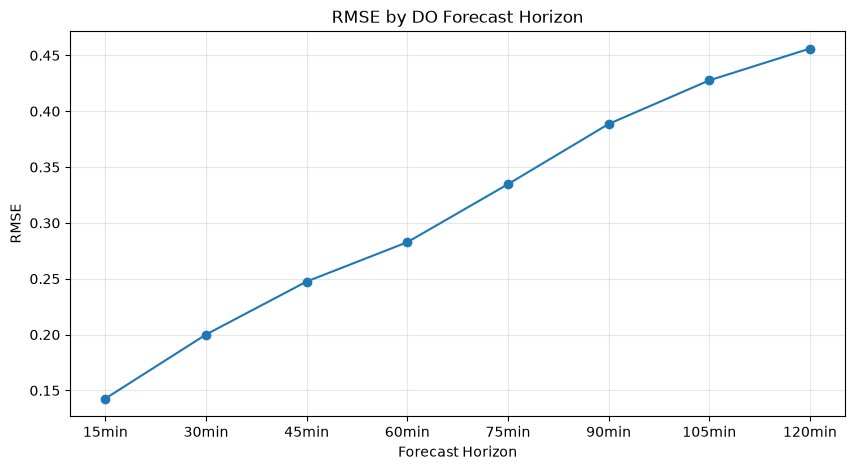

In [3]:
plt.figure(figsize=(10, 5))

plt.plot(
    best["horizon"],
    best["RMSE"],
    marker="o"
)

plt.title("RMSE by DO Forecast Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.grid(alpha=0.3)
plt.show()

## Interpretation

Forecast error generally increases as the prediction horizon becomes longer. This reflects the increasing uncertainty involved in predicting river conditions further into the future.

The results therefore demonstrate the trade-off between forecast lead time and prediction accuracy.